--------------------------------------------------
Grid spacing dx = 4.166319e-04
Smallest hbar   = 3.000000e-02
Current n_grid  = 12000
Suggested n_grid for conservative resolution: 1334
--------------------------------------------------
hbar=  0.160000  ||diff||= 6.86465e-01  ||diff||/hbar= 4.29041e+00  split= 1.06737e-03  loc_mass= 0.999787  flea_idx= 0  overlap= 0.764383  flea_mass= 0.584247  <x>_flea= -0.156749
hbar=  0.152922  ||diff||= 6.52619e-01  ||diff||/hbar= 4.26765e+00  split= 7.14873e-04  loc_mass= 0.999861  flea_idx= 0  overlap= 0.787044  flea_mass= 0.619406  <x>_flea= -0.223046
hbar=  0.146158  ||diff||= 6.03371e-01  ||diff||/hbar= 4.12821e+00  split= 4.70086e-04  loc_mass= 0.999911  flea_idx= 0  overlap= 0.817972  flea_mass= 0.669048  <x>_flea= -0.316942
hbar=  0.139693  ||diff||= 5.33881e-01  ||diff||/hbar= 3.82182e+00  split= 3.03265e-04  loc_mass= 0.999944  flea_idx= 0  overlap= 0.857485  flea_mass= 0.735255  <x>_flea= -0.442590
hbar=  0.133514  ||diff||= 4.42868e-0

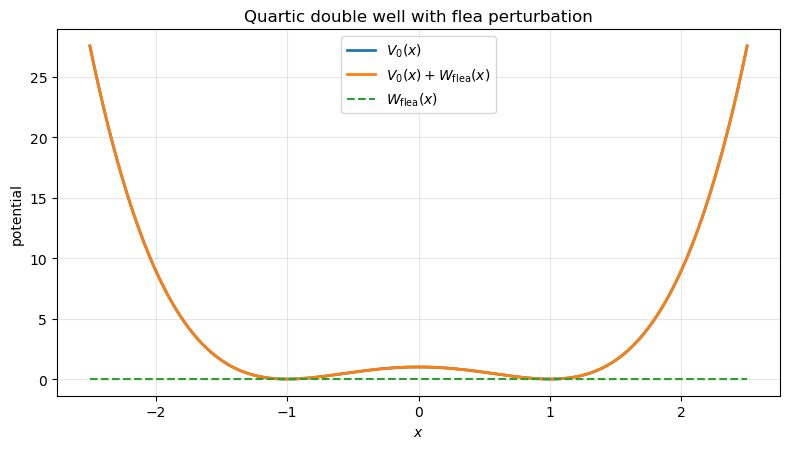

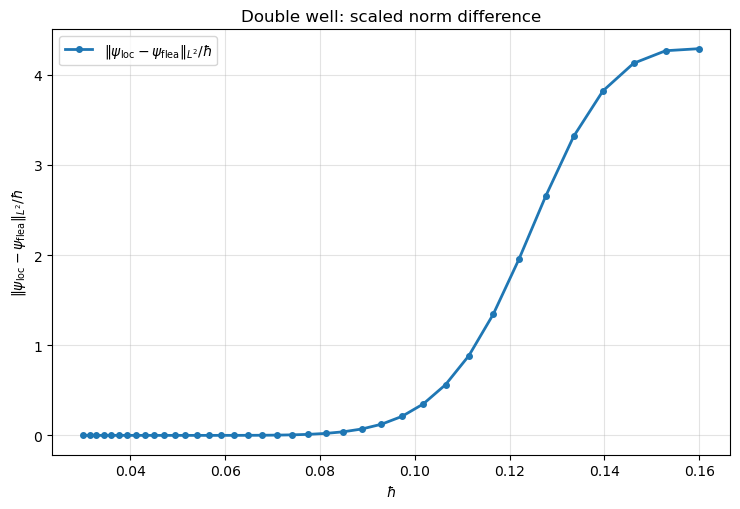

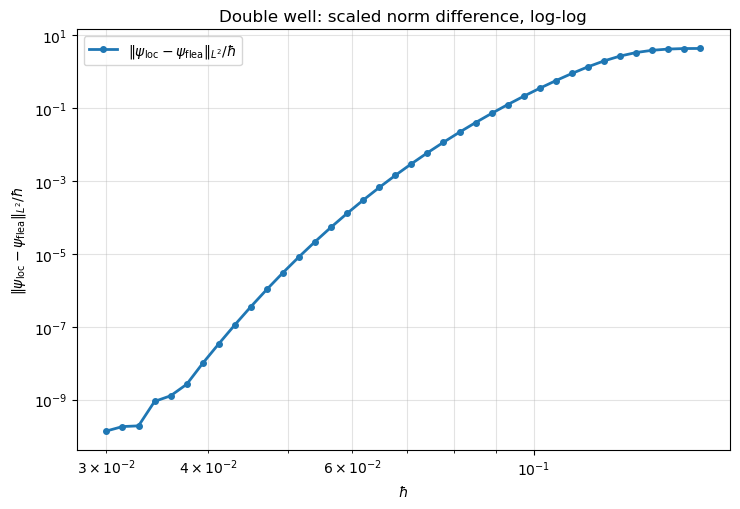

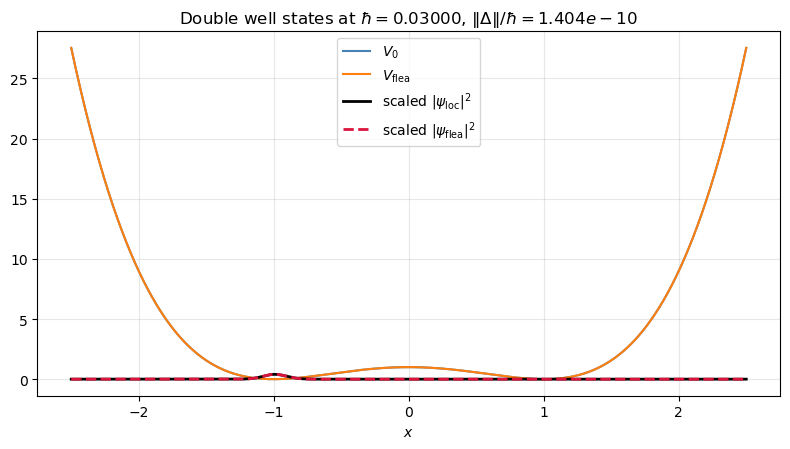

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import diags
from scipy.sparse.linalg import eigsh


# ============================================================
# Grid and numerical-resolution helpers
# ============================================================

def recommended_n_grid_for_double_well(
    L,
    hbar_min,
    flea_width=None,
    points_per_sqrt_hbar=35,
    points_per_hbar=8,
    points_per_flea_width=18
):
    """
    Conservative grid-size recommendation for small-hbar finite differences.

    The relevant small length scales are roughly sqrt(hbar), hbar, and the flea width.
    """
    dx_targets = [
        np.sqrt(hbar_min) / points_per_sqrt_hbar,
        hbar_min / points_per_hbar,
    ]

    if flea_width is not None:
        dx_targets.append(flea_width / points_per_flea_width)

    dx_target = min(dx_targets)
    period_length = 2.0 * L

    return int(np.ceil(period_length / dx_target))


def make_dirichlet_grid(L=2.5, n_grid=12000):
    """
    Interior grid for Dirichlet boundary conditions on [-L, L].

    Boundary points are excluded:
        psi(-L) = psi(L) = 0.
    """
    dx = 2.0 * L / (n_grid + 1)
    x = np.linspace(-L + dx, L - dx, n_grid)
    return x, dx


# ============================================================
# Potentials
# ============================================================

def quartic_double_well(x, a=1.0, lam=4.0):
    """
    Symmetric quartic double well:

        V(x) = lam / 4 * (x^2 - a^2)^2.

    With a = 1 and lam = 4:

        V(x) = (x^2 - 1)^2,

    which has minima at x = +/-1 and barrier height 1.
    """
    return 0.25 * lam * (x**2 - a**2)**2


def smooth_compact_bump(x, center, width, height):
    """
    Smooth compactly supported bump.

    W(x) = height * exp(1/width^2 - 1/(width^2 - (x-center)^2))

    for |x-center| < width, and 0 otherwise.
    """
    W = np.zeros_like(x, dtype=float)
    r = x - center
    mask = np.abs(r) < width

    exponent = (1.0 / width**2) - (1.0 / (width**2 - r[mask]**2))
    W[mask] = height * np.exp(exponent)

    return W


# ============================================================
# Sparse Dirichlet Hamiltonian
# ============================================================

def build_dirichlet_hamiltonian_sparse(x, dx, V, hbar, mass=0.5):
    """
    Sparse second-order finite-difference Hamiltonian with Dirichlet boundaries.

    H = -hbar^2 / (2m) d^2/dx^2 + V(x)

    Interior finite-difference stencil:

        psi''(x_i) approx (psi_{i+1} - 2 psi_i + psi_{i-1}) / dx^2.

    Hence

        diagonal kinetic  = hbar^2 / (m dx^2)
        offdiag kinetic   = -hbar^2 / (2m dx^2).
    """
    n = len(x)

    diag_kinetic = hbar**2 / (mass * dx**2)
    offdiag_kinetic = -hbar**2 / (2.0 * mass * dx**2)

    main_diag = diag_kinetic + V
    off_diag = offdiag_kinetic * np.ones(n - 1)

    H = diags(
        diagonals=[off_diag, main_diag, off_diag],
        offsets=[-1, 0, 1],
        format="csr"
    )

    return H


def solve_lowest_dirichlet_eigenstates(
    x,
    dx,
    V,
    hbar,
    mass=0.5,
    k=8,
    tol=1e-12,
    ncv=None,
    sigma_shift=-0.02,
    maxiter=500000
):
    """
    Solve the sparse Dirichlet finite-difference eigenproblem.

    Uses shift-invert mode:

        eigsh(H, sigma=sigma_shift, which="LM")

    with sigma_shift typically slightly negative, so the eigenvalues closest to it
    are the lowest positive eigenvalues of the Hamiltonian.

    Returned eigenvectors are continuum-normalized:

        dx * sum_i |psi_i|^2 = 1.
    """
    H = build_dirichlet_hamiltonian_sparse(
        x=x,
        dx=dx,
        V=V,
        hbar=hbar,
        mass=mass
    )

    n = len(x)

    if ncv is None:
        ncv = min(n - 1, max(4 * k + 20, 100))

    try:
        evals, evecs = eigsh(
            H,
            k=k,
            sigma=sigma_shift,
            which="LM",
            tol=tol,
            ncv=ncv,
            maxiter=maxiter
        )
    except Exception as exc:
        print("Shift-invert eigsh failed. Falling back to which='SA'.")
        print("Failure message:", repr(exc))

        evals, evecs = eigsh(
            H,
            k=k,
            which="SA",
            tol=tol,
            ncv=ncv,
            maxiter=maxiter
        )

    idx = np.argsort(evals)
    evals = evals[idx]
    evecs = evecs[:, idx]

    # eigsh returns Euclidean-normalized eigenvectors.
    # Convert to continuum L2 normalization.
    evecs = evecs / np.sqrt(dx)

    return evals, evecs


# ============================================================
# L2 utilities
# ============================================================

def l2_inner(dx, psi, phi):
    return dx * np.vdot(psi, phi)


def l2_norm(dx, psi):
    return np.sqrt(np.real(l2_inner(dx, psi, psi)))


def normalize_l2(dx, psi):
    return psi / l2_norm(dx, psi)


def align_phase(dx, reference, psi):
    """
    Align the global phase of psi with reference so that their overlap is real
    and nonnegative.
    """
    overlap = l2_inner(dx, reference, psi)

    if np.abs(overlap) < 1e-14:
        return psi

    return psi * np.exp(-1j * np.angle(overlap))


# ============================================================
# State construction
# ============================================================

def smooth_well_window(x, target_well="left", transition_width=0.20):
    """
    Smooth window for selecting left or right well.

    For left:
        window approx 1 for x < 0, approx 0 for x > 0.

    For right:
        window approx 0 for x < 0, approx 1 for x > 0.

    This avoids using a sharp discontinuous projector at x = 0.
    """
    if target_well == "left":
        return 0.5 * (1.0 - np.tanh(x / transition_width))
    elif target_well == "right":
        return 0.5 * (1.0 + np.tanh(x / transition_width))
    else:
        raise ValueError("target_well must be 'left' or 'right'.")


def localized_state_from_unperturbed_doublet(
    x,
    dx,
    evecs,
    target_well="left",
    method="position",
    window_transition_width=0.20
):
    """
    Construct an approximately localized unperturbed state from the lowest
    two unperturbed eigenfunctions.

    Two robust options:

    method="position":
        Diagonalize the position operator x restricted to span{psi_0, psi_1}.
        Select the eigenvector with negative/positive position expectation.

    method="smooth_window":
        Diagonalize a smooth left/right well window restricted to span{psi_0, psi_1}.
        Select the state with largest window expectation.
    """
    Phi = evecs[:, :2]

    if method == "position":
        Op_projected = dx * (Phi.conj().T @ (x[:, None] * Phi))
        vals, coeffs = np.linalg.eigh(Op_projected)

        if target_well == "left":
            idx = int(np.argmin(vals))
        elif target_well == "right":
            idx = int(np.argmax(vals))
        else:
            raise ValueError("target_well must be 'left' or 'right'.")

    elif method == "smooth_window":
        w = smooth_well_window(
            x,
            target_well=target_well,
            transition_width=window_transition_width
        )
        Op_projected = dx * (Phi.conj().T @ (w[:, None] * Phi))
        vals, coeffs = np.linalg.eigh(Op_projected)
        idx = int(np.argmax(vals))

    else:
        raise ValueError("method must be 'position' or 'smooth_window'.")

    psi_loc = Phi @ coeffs[:, idx]
    psi_loc = normalize_l2(dx, psi_loc)

    return psi_loc


def choose_flea_state_by_overlap(dx, psi_loc, flea_evecs, n_candidates=8):
    """
    Choose the flea eigenstate with maximal absolute L2 overlap with psi_loc.

    This is more reliable than choosing by well mass only.
    """
    n_candidates = min(n_candidates, flea_evecs.shape[1])

    best_idx = None
    best_overlap = -np.inf

    for j in range(n_candidates):
        psi = flea_evecs[:, j]
        overlap = np.abs(l2_inner(dx, psi_loc, psi))

        if overlap > best_overlap:
            best_overlap = overlap
            best_idx = j

    psi_best = normalize_l2(dx, flea_evecs[:, best_idx])

    return psi_best, best_idx, best_overlap


def well_mass_and_center(x, dx, psi, target_well="left"):
    """
    Diagnostics: probability mass in target well and position expectation.
    """
    if target_well == "left":
        mask = x < 0.0
    elif target_well == "right":
        mask = x > 0.0
    else:
        raise ValueError("target_well must be 'left' or 'right'.")

    mass = dx * np.sum(np.abs(psi[mask])**2)
    center = np.real(l2_inner(dx, psi, x * psi))

    return mass, center


# ============================================================
# Main computation
# ============================================================

def compute_double_well_scaled_errors(
    hbars,
    L=2.5,
    n_grid=12000,
    mass=0.5,
    a=1.0,
    lam=4.0,
    target_well="left",
    flea_center_abs=0.65,
    flea_width=0.12,
    flea_height=0.010,
    n_unperturbed_states=6,
    n_flea_states=10,
    n_flea_candidates=10,
    eig_tol=1e-12,
    sigma_shift=-0.02,
    localization_method="position",
    window_transition_width=0.20,
    print_resolution_warning=True
):
    """
    For each hbar, compute:

        psi_loc:
            normalized linear combination of the lowest two unperturbed
            eigenstates, localized in target_well.

        psi_flea:
            flea-perturbed eigenstate with maximal overlap with psi_loc.

    Then compute:

        error(hbar) = ||psi_loc - psi_flea||_L2

    and

        scaled_error(hbar) = error(hbar) / hbar.

    A positive flea is placed in the opposite well:
        target left  -> flea in right well
        target right -> flea in left well.
    """
    x, dx = make_dirichlet_grid(L=L, n_grid=n_grid)

    hbar_min = np.min(hbars)

    if print_resolution_warning:
        suggested = recommended_n_grid_for_double_well(
            L=L,
            hbar_min=hbar_min,
            flea_width=flea_width
        )
        print("--------------------------------------------------")
        print(f"Grid spacing dx = {dx:.6e}")
        print(f"Smallest hbar   = {hbar_min:.6e}")
        print(f"Current n_grid  = {n_grid}")
        print(f"Suggested n_grid for conservative resolution: {suggested}")
        if n_grid < suggested:
            print("WARNING: n_grid may be too small for the smallest hbar.")
            print("         Increase n_grid or avoid the smallest hbar values.")
        print("--------------------------------------------------")

    V0 = quartic_double_well(x, a=a, lam=lam)

    # Put a positive flea in the opposite well.
    if target_well == "left":
        flea_center = +flea_center_abs
    elif target_well == "right":
        flea_center = -flea_center_abs
    else:
        raise ValueError("target_well must be 'left' or 'right'.")

    W_flea = smooth_compact_bump(
        x=x,
        center=flea_center,
        width=flea_width,
        height=flea_height
    )

    V_flea = V0 + W_flea

    errors = []
    scaled_errors = []
    records = []

    for hbar in hbars:
        # ----------------------------------------------------
        # Unperturbed double well
        # ----------------------------------------------------
        evals0, evecs0 = solve_lowest_dirichlet_eigenstates(
            x=x,
            dx=dx,
            V=V0,
            hbar=hbar,
            mass=mass,
            k=n_unperturbed_states,
            tol=eig_tol,
            sigma_shift=sigma_shift
        )

        psi_loc = localized_state_from_unperturbed_doublet(
            x=x,
            dx=dx,
            evecs=evecs0,
            target_well=target_well,
            method=localization_method,
            window_transition_width=window_transition_width
        )

        loc_mass, loc_center = well_mass_and_center(
            x=x,
            dx=dx,
            psi=psi_loc,
            target_well=target_well
        )

        # ----------------------------------------------------
        # Flea-perturbed double well
        # ----------------------------------------------------
        evals_flea, evecs_flea = solve_lowest_dirichlet_eigenstates(
            x=x,
            dx=dx,
            V=V_flea,
            hbar=hbar,
            mass=mass,
            k=n_flea_states,
            tol=eig_tol,
            sigma_shift=sigma_shift
        )

        psi_flea, flea_idx, flea_overlap = choose_flea_state_by_overlap(
            dx=dx,
            psi_loc=psi_loc,
            flea_evecs=evecs_flea,
            n_candidates=n_flea_candidates
        )

        psi_flea = align_phase(dx, psi_loc, psi_flea)

        flea_mass, flea_center_expectation = well_mass_and_center(
            x=x,
            dx=dx,
            psi=psi_flea,
            target_well=target_well
        )

        # ----------------------------------------------------
        # L2 error and scaled error
        # ----------------------------------------------------
        error = l2_norm(dx, psi_loc - psi_flea)
        scaled_error = error / hbar

        errors.append(error)
        scaled_errors.append(scaled_error)

        records.append({
            "hbar": hbar,
            "error": error,
            "scaled_error": scaled_error,
            "E0_unperturbed": evals0[0],
            "E1_unperturbed": evals0[1],
            "unperturbed_splitting": evals0[1] - evals0[0],
            "loc_mass": loc_mass,
            "loc_center": loc_center,
            "flea_state_index": flea_idx,
            "flea_overlap": flea_overlap,
            "E_flea_selected": evals_flea[flea_idx],
            "flea_mass": flea_mass,
            "flea_center": flea_center_expectation
        })

        print(
            f"hbar={hbar:10.6f}  "
            f"||diff||={error:12.5e}  "
            f"||diff||/hbar={scaled_error:12.5e}  "
            f"split={evals0[1] - evals0[0]:12.5e}  "
            f"loc_mass={loc_mass:9.6f}  "
            f"flea_idx={flea_idx:2d}  "
            f"overlap={flea_overlap:9.6f}  "
            f"flea_mass={flea_mass:9.6f}  "
            f"<x>_flea={flea_center_expectation:10.6f}"
        )

    return {
        "x": x,
        "dx": dx,
        "L": L,
        "V0": V0,
        "W_flea": W_flea,
        "V_flea": V_flea,
        "hbars": np.array(hbars),
        "errors": np.array(errors),
        "scaled_errors": np.array(scaled_errors),
        "records": records
    }


# ============================================================
# Plotting
# ============================================================

def plot_potentials(results):
    x = results["x"]
    V0 = results["V0"]
    W = results["W_flea"]
    Vf = results["V_flea"]

    fig, ax = plt.subplots(figsize=(8.0, 4.6))

    ax.plot(x, V0, lw=2, label=r"$V_0(x)$")
    ax.plot(x, Vf, lw=2, label=r"$V_0(x)+W_{\rm flea}(x)$")
    ax.plot(x, W, "--", lw=1.5, label=r"$W_{\rm flea}(x)$")

    ax.set_xlabel(r"$x$")
    ax.set_ylabel("potential")
    ax.set_title("Quartic double well with flea perturbation")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()


def plot_scaled_errors(results):
    hbars = results["hbars"]
    scaled_errors = results["scaled_errors"]

    order = np.argsort(hbars)
    hbars_sorted = hbars[order]
    scaled_sorted = scaled_errors[order]

    fig, ax = plt.subplots(figsize=(7.5, 5.2))

    ax.plot(
        hbars_sorted,
        scaled_sorted,
        "o-",
        lw=2,
        ms=4,
        label=r"$\|\psi_{\rm loc}-\psi_{\rm flea}\|_{L^2}/\hbar$"
    )

    ax.set_xlabel(r"$\hbar$")
    ax.set_ylabel(r"$\|\psi_{\rm loc}-\psi_{\rm flea}\|_{L^2}/\hbar$")
    ax.set_title(r"Double well: scaled norm difference")
    ax.grid(True, alpha=0.35)
    ax.legend()

    plt.tight_layout()
    plt.show()


def plot_scaled_errors_loglog(results):
    hbars = results["hbars"]
    scaled_errors = results["scaled_errors"]

    order = np.argsort(hbars)
    hbars_sorted = hbars[order]
    scaled_sorted = scaled_errors[order]

    fig, ax = plt.subplots(figsize=(7.5, 5.2))

    ax.loglog(
        hbars_sorted,
        scaled_sorted,
        "o-",
        lw=2,
        ms=4,
        label=r"$\|\psi_{\rm loc}-\psi_{\rm flea}\|_{L^2}/\hbar$"
    )

    ax.set_xlabel(r"$\hbar$")
    ax.set_ylabel(r"$\|\psi_{\rm loc}-\psi_{\rm flea}\|_{L^2}/\hbar$")
    ax.set_title(r"Double well: scaled norm difference, log-log")
    ax.grid(True, which="both", alpha=0.35)
    ax.legend()

    plt.tight_layout()
    plt.show()


def plot_example_states_for_one_hbar(
    hbar,
    results,
    mass=0.5,
    target_well="left",
    n_unperturbed_states=6,
    n_flea_states=10,
    n_flea_candidates=10,
    eig_tol=1e-12,
    sigma_shift=-0.02,
    localization_method="position",
    window_transition_width=0.20
):
    """
    Diagnostic plot of psi_loc and psi_flea densities for one hbar.
    """
    x = results["x"]
    dx = results["dx"]
    V0 = results["V0"]
    V_flea = results["V_flea"]

    evals0, evecs0 = solve_lowest_dirichlet_eigenstates(
        x=x,
        dx=dx,
        V=V0,
        hbar=hbar,
        mass=mass,
        k=n_unperturbed_states,
        tol=eig_tol,
        sigma_shift=sigma_shift
    )

    psi_loc = localized_state_from_unperturbed_doublet(
        x=x,
        dx=dx,
        evecs=evecs0,
        target_well=target_well,
        method=localization_method,
        window_transition_width=window_transition_width
    )

    evals_flea, evecs_flea = solve_lowest_dirichlet_eigenstates(
        x=x,
        dx=dx,
        V=V_flea,
        hbar=hbar,
        mass=mass,
        k=n_flea_states,
        tol=eig_tol,
        sigma_shift=sigma_shift
    )

    psi_flea, flea_idx, flea_overlap = choose_flea_state_by_overlap(
        dx=dx,
        psi_loc=psi_loc,
        flea_evecs=evecs_flea,
        n_candidates=n_flea_candidates
    )

    psi_flea = align_phase(dx, psi_loc, psi_flea)

    error = l2_norm(dx, psi_loc - psi_flea)

    fig, ax = plt.subplots(figsize=(8.0, 4.6))

    ax.plot(x, V0, color="steelblue", lw=1.5, label=r"$V_0$")
    ax.plot(x, V_flea, color="tab:orange", lw=1.5, label=r"$V_{\rm flea}$")

    density_loc = np.abs(psi_loc)**2
    density_flea = np.abs(psi_flea)**2

    scale = 0.40 / max(np.max(density_loc), np.max(density_flea))

    ax.plot(
        x,
        scale * density_loc,
        color="black",
        lw=2,
        label=r"scaled $|\psi_{\rm loc}|^2$"
    )

    ax.plot(
        x,
        scale * density_flea,
        color="crimson",
        lw=2,
        ls="--",
        label=r"scaled $|\psi_{\rm flea}|^2$"
    )

    ax.set_xlabel(r"$x$")
    ax.set_title(
        rf"Double well states at $\hbar={hbar:.5f}$, "
        rf"$\|\Delta\|/\hbar={error / hbar:.3e}$"
    )
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()


def grid_convergence_study(
    hbars,
    grid_sizes,
    **kwargs
):
    """
    Run the same calculation at multiple grid sizes to check numerical convergence.
    """
    all_results = []

    fig, ax = plt.subplots(figsize=(7.8, 5.4))

    for n_grid in grid_sizes:
        print("\n==================================================")
        print(f"Running n_grid = {n_grid}")
        print("==================================================")

        results = compute_double_well_scaled_errors(
            hbars=hbars,
            n_grid=n_grid,
            print_resolution_warning=False,
            **kwargs
        )

        all_results.append(results)

        order = np.argsort(results["hbars"])
        ax.plot(
            results["hbars"][order],
            results["scaled_errors"][order],
            "o-",
            lw=1.8,
            ms=3,
            label=f"n_grid={n_grid}"
        )

    ax.set_xlabel(r"$\hbar$")
    ax.set_ylabel(r"$\|\psi_{\rm loc}-\psi_{\rm flea}\|_{L^2}/\hbar$")
    ax.set_title("Grid convergence study")
    ax.grid(True, alpha=0.35)
    ax.legend()

    plt.tight_layout()
    plt.show()

    return all_results


# ============================================================
# Run script
# ============================================================

if __name__ == "__main__":

    # Avoid going too small until grid convergence has been checked.
    hbars = np.geomspace(0.16, 0.030, 38)

    results = compute_double_well_scaled_errors(
        hbars=hbars,

        # Geometry and grid
        L=2.5,
        n_grid=12000,

        # Hamiltonian parameters
        mass=0.5,
        a=1.0,
        lam=4.0,

        # Target localization
        target_well="left",

        # Flea parameters.
        # Positive flea in the opposite well.
        # If small-hbar states look distorted, reduce flea_height.
        flea_center_abs=0.65,
        flea_width=0.12,
        flea_height=0.010,

        # Eigensolver settings
        n_unperturbed_states=6,
        n_flea_states=10,
        n_flea_candidates=10,
        eig_tol=1e-12,
        sigma_shift=-0.02,

        # Localized unperturbed state construction
        localization_method="position",
        # localization_method="smooth_window",
        window_transition_width=0.20,

        print_resolution_warning=True
    )

    plot_potentials(results)
    plot_scaled_errors(results)
    plot_scaled_errors_loglog(results)

    # Diagnostic plot at smallest hbar
    plot_example_states_for_one_hbar(
        hbar=results["hbars"][-1],
        results=results,
        mass=0.5,
        target_well="left",
        n_unperturbed_states=6,
        n_flea_states=10,
        n_flea_candidates=10,
        eig_tol=1e-12,
        sigma_shift=-0.02,
        localization_method="position",
        window_transition_width=0.20
    )

    # Optional grid convergence study.
    # Uncomment if needed.
    #
    # grid_convergence_study(
    #     hbars=np.geomspace(0.12, 0.035, 20),
    #     grid_sizes=[6000, 9000, 12000, 16000],
    #     L=2.5,
    #     mass=0.5,
    #     a=1.0,
    #     lam=4.0,
    #     target_well="left",
    #     flea_center_abs=0.65,
    #     flea_width=0.12,
    #     flea_height=0.010,
    #     n_unperturbed_states=6,
    #     n_flea_states=10,
    #     n_flea_candidates=10,
    #     eig_tol=1e-12,
    #     sigma_shift=-0.02,
    #     localization_method="position",
    #     window_transition_width=0.20
    # )

--------------------------------------------------
Period          = 6.000000e+00
Grid spacing dx = 6.666667e-04
Smallest hbar   = 3.000000e-02
Current n_grid  = 9000
Suggested n_grid for conservative resolution: 1600
--------------------------------------------------
hbar=  0.160000  ||diff||= 7.57098e-01  ||diff||/hbar= 4.73186e+00  band_width= 1.04220e-03  loc_mass= 0.999743  flea_idx= 1  overlap= 0.713401  flea_mass= 0.508175  flea_center=  1.794179
hbar=  0.153278  ||diff||= 7.40285e-01  ||diff||/hbar= 4.82970e+00  band_width= 7.24703e-04  loc_mass= 0.999826  flea_idx= 0  overlap= 0.725989  flea_mass= 0.527553  flea_center=  1.209179
hbar=  0.146838  ||diff||= 6.58387e-01  ||diff||/hbar= 4.48377e+00  band_width= 4.95995e-04  loc_mass= 0.999883  flea_idx= 0  overlap= 0.783263  flea_mass= 0.613833  flea_center=  1.151490
hbar=  0.140669  ||diff||= 5.45355e-01  ||diff||/hbar= 3.87688e+00  band_width= 3.33917e-04  loc_mass= 0.999923  flea_idx= 0  overlap= 0.851294  flea_mass= 0.724903

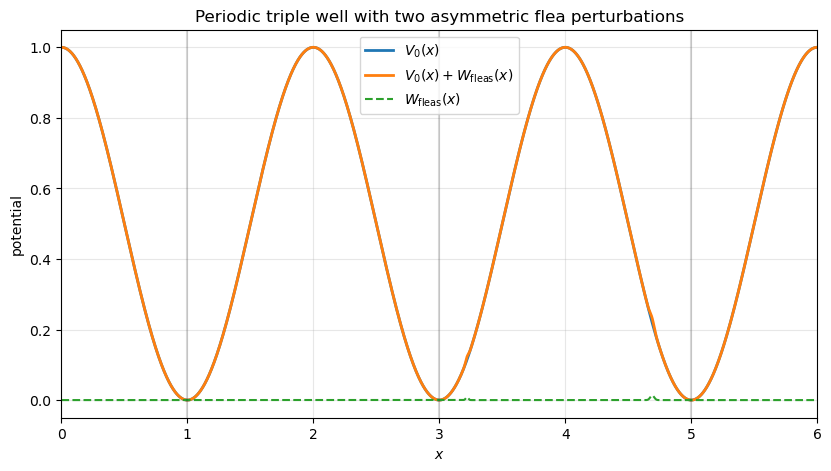

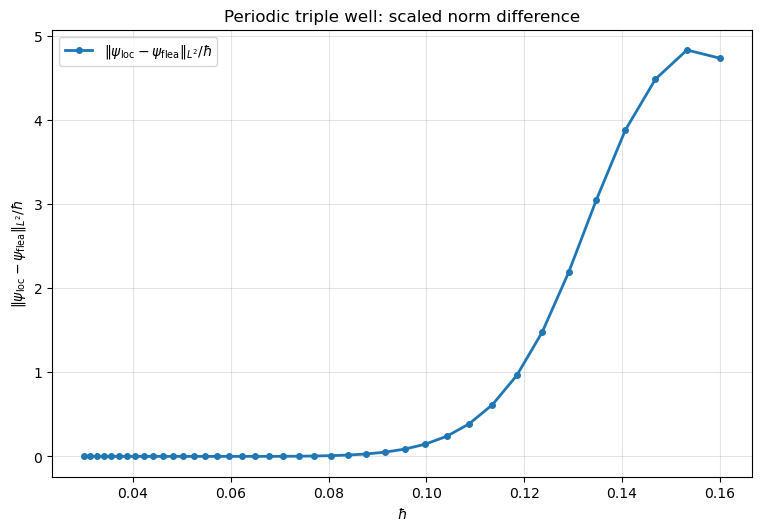

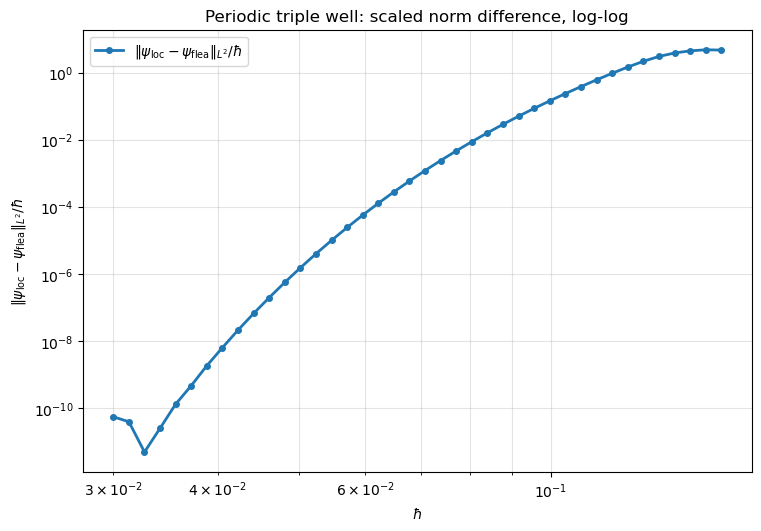

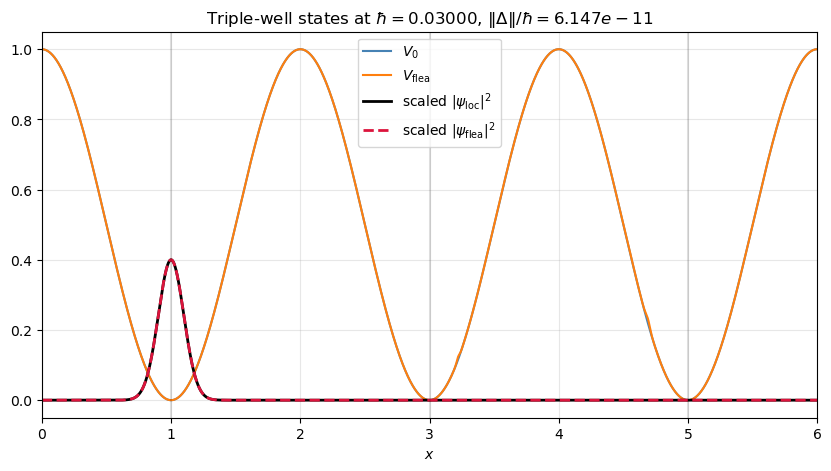

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import diags
from scipy.sparse.linalg import eigsh


# ============================================================
# Grid and numerical-resolution helpers
# ============================================================

def recommended_n_grid_periodic(
    period,
    hbar_min,
    min_flea_width=None,
    points_per_sqrt_hbar=35,
    points_per_hbar=8,
    points_per_flea_width=18
):
    """
    Conservative grid-size recommendation for small-hbar finite differences.
    """
    dx_targets = [
        np.sqrt(hbar_min) / points_per_sqrt_hbar,
        hbar_min / points_per_hbar,
    ]

    if min_flea_width is not None:
        dx_targets.append(min_flea_width / points_per_flea_width)

    dx_target = min(dx_targets)
    return int(np.ceil(period / dx_target))


def make_periodic_grid(period=6.0, n_grid=9000):
    """
    Periodic grid on [0, period).

    Endpoint is excluded, so x = 0 and x = period are identified.
    """
    dx = period / n_grid
    x = np.linspace(0.0, period, n_grid, endpoint=False)
    return x, dx


def periodic_distance(x, center, period):
    """
    Signed shortest periodic distance from x to center on a circle of length period.
    """
    return (x - center + 0.5 * period) % period - 0.5 * period


# ============================================================
# Periodic triple-well potential and fleas
# ============================================================

def periodic_triple_well_cos2(x, a=1.0, barrier_height=1.0):
    """
    Periodic triple-well potential on [0, 6a):

        V(x) = barrier_height * cos^2(pi x / (2a)).

    Minima occur at x = a, 3a, 5a.
    """
    return barrier_height * np.cos(np.pi * x / (2.0 * a))**2


def smooth_periodic_bump(x, center, width, height, period):
    """
    Smooth compactly supported periodic bump.

    Let r be the shortest periodic distance from x to center.

        W(x) = height * exp(1/width^2 - 1/(width^2 - r^2))

    for |r| < width, and 0 otherwise.
    """
    r = periodic_distance(x, center, period)

    W = np.zeros_like(x, dtype=float)
    mask = np.abs(r) < width

    exponent = (1.0 / width**2) - (1.0 / (width**2 - r[mask]**2))
    W[mask] = height * np.exp(exponent)

    return W


def build_asymmetric_two_flea_potential(
    x,
    period,
    well_centers,
    target_well_index=0,
    flea_widths=(0.12, 0.15),
    flea_heights=(0.008, 0.013),
    flea_offsets=(0.22, -0.31)
):
    """
    Add asymmetric positive fleas in the two wells that are NOT the target well.
    This fully breaks the threefold symmetry.
    """
    if not (len(flea_widths) == len(flea_heights) == len(flea_offsets) == 2):
        raise ValueError("flea_widths, flea_heights, and flea_offsets must each have length 2.")

    W_total = np.zeros_like(x, dtype=float)
    non_target_indices = [j for j in range(3) if j != target_well_index]

    for k, well_idx in enumerate(non_target_indices):
        center = (well_centers[well_idx] + flea_offsets[k]) % period

        W_total += smooth_periodic_bump(
            x=x,
            center=center,
            width=flea_widths[k],
            height=flea_heights[k],
            period=period
        )

    return W_total


# ============================================================
# Sparse periodic Hamiltonian
# ============================================================

def build_periodic_hamiltonian_sparse(x, dx, V, hbar, mass=0.5):
    """
    Sparse periodic finite-difference Hamiltonian

        H = -hbar^2 / (2m) d^2/dx^2 + V(x).

    Periodic wraparound is included.
    """
    n = len(x)

    diag_kinetic = hbar**2 / (mass * dx**2)
    offdiag_kinetic = -hbar**2 / (2.0 * mass * dx**2)

    main_diag = diag_kinetic + V
    off_diag = offdiag_kinetic * np.ones(n - 1)

    H = diags(
        diagonals=[off_diag, main_diag, off_diag],
        offsets=[-1, 0, 1],
        format="lil"
    )

    H[0, -1] = offdiag_kinetic
    H[-1, 0] = offdiag_kinetic

    return H.tocsr()


def solve_lowest_periodic_eigenstates(
    x,
    dx,
    V,
    hbar,
    mass=0.5,
    k=12,
    tol=1e-12,
    ncv=None,
    sigma_shift=-0.02,
    maxiter=500000
):
    """
    Solve the sparse periodic finite-difference eigenproblem.

    Uses shift-invert mode by default:

        eigsh(H, sigma=sigma_shift, which="LM")

    Returned eigenvectors are continuum-normalized:

        dx * sum_i |psi_i|^2 = 1.
    """
    H = build_periodic_hamiltonian_sparse(
        x=x,
        dx=dx,
        V=V,
        hbar=hbar,
        mass=mass
    )

    n = len(x)

    if ncv is None:
        ncv = min(n - 1, max(4 * k + 20, 100))

    try:
        evals, evecs = eigsh(
            H,
            k=k,
            sigma=sigma_shift,
            which="LM",
            tol=tol,
            ncv=ncv,
            maxiter=maxiter
        )
    except Exception as exc:
        print("Shift-invert eigsh failed. Falling back to which='SA'.")
        print("Failure message:", repr(exc))

        evals, evecs = eigsh(
            H,
            k=k,
            which="SA",
            tol=tol,
            ncv=ncv,
            maxiter=maxiter
        )

    idx = np.argsort(evals)
    evals = evals[idx]
    evecs = evecs[:, idx]

    # Convert Euclidean normalization to continuum L2 normalization.
    evecs = evecs / np.sqrt(dx)

    return evals, evecs


# ============================================================
# L2 utilities
# ============================================================

def l2_inner(dx, psi, phi):
    return dx * np.vdot(psi, phi)


def l2_norm(dx, psi):
    return np.sqrt(np.real(l2_inner(dx, psi, psi)))


def normalize_l2(dx, psi):
    return psi / l2_norm(dx, psi)


def align_phase(dx, reference, psi):
    """
    Align global phase of psi with reference so overlap is real and nonnegative.
    """
    overlap = l2_inner(dx, reference, psi)

    if np.abs(overlap) < 1e-14:
        return psi

    return psi * np.exp(-1j * np.angle(overlap))


# ============================================================
# Well-localization tools
# ============================================================

def nearest_well_indices(x, well_centers, period):
    """
    For each grid point, return the index of the nearest well center.
    """
    distances = []

    for c in well_centers:
        distances.append(np.abs(periodic_distance(x, c, period)))

    distances = np.vstack(distances)
    return np.argmin(distances, axis=0)


def well_mask(x, well_centers, target_well_index, period):
    """
    Boolean mask selecting the Voronoi cell of the target well.
    """
    nearest = nearest_well_indices(x, well_centers, period)
    return nearest == target_well_index


def smooth_periodic_target_window(x, center, period, sigma=0.45):
    """
    Smooth periodic Gaussian-like window centered at the target well.
    """
    r = periodic_distance(x, center, period)
    w = np.exp(-0.5 * (r / sigma)**2)
    return w / np.max(w)


def localized_state_from_unperturbed_triple_band(
    x,
    dx,
    evecs,
    target_mask,
    well_centers,
    target_well_index,
    period,
    method="smooth_window",
    window_sigma=0.45
):
    """
    Construct the approximately localized unperturbed state from the lowest
    three unperturbed eigenstates.

    method="smooth_window":
        Diagonalize a smooth periodic target-well window in the 3D low-energy band.

    method="target_cell":
        Diagonalize the sharp target-cell projection in the 3D low-energy band.
    """
    Phi = evecs[:, :3]

    if method == "smooth_window":
        target_center = well_centers[target_well_index]
        w = smooth_periodic_target_window(
            x=x,
            center=target_center,
            period=period,
            sigma=window_sigma
        )
        Op_projected = dx * (Phi.conj().T @ (w[:, None] * Phi))

    elif method == "target_cell":
        Op_projected = dx * (Phi.conj().T @ (target_mask[:, None] * Phi))

    else:
        raise ValueError("method must be 'smooth_window' or 'target_cell'.")

    vals, coeffs = np.linalg.eigh(Op_projected)
    idx = int(np.argmax(vals))

    psi_loc = Phi @ coeffs[:, idx]
    psi_loc = normalize_l2(dx, psi_loc)

    return psi_loc, vals[idx]


def choose_flea_state_by_overlap(dx, psi_loc, flea_evecs, n_candidates=12):
    """
    Choose the flea eigenstate with maximal absolute L2 overlap with psi_loc.
    """
    n_candidates = min(n_candidates, flea_evecs.shape[1])

    best_idx = None
    best_overlap = -np.inf

    for j in range(n_candidates):
        psi = flea_evecs[:, j]
        overlap = np.abs(l2_inner(dx, psi_loc, psi))

        if overlap > best_overlap:
            best_overlap = overlap
            best_idx = j

    psi_best = normalize_l2(dx, flea_evecs[:, best_idx])

    return psi_best, best_idx, best_overlap


def target_well_mass(dx, psi, target_mask):
    """
    Probability mass in the target well cell.
    """
    return dx * np.sum(np.abs(psi[target_mask])**2)


def circular_mean_position(x, dx, psi, period):
    """
    Circular mean position on [0, period). Useful for periodic geometry.
    """
    density = np.abs(psi)**2
    theta = 2.0 * np.pi * x / period

    z = dx * np.sum(density * np.exp(1j * theta))

    angle = np.angle(z)
    if angle < 0:
        angle += 2.0 * np.pi

    return period * angle / (2.0 * np.pi)


# ============================================================
# Main computation
# ============================================================

def compute_triple_well_scaled_errors(
    hbars,
    a=1.0,
    n_grid=9000,
    mass=0.5,
    barrier_height=1.0,
    target_well_index=0,
    flea_widths=(0.12, 0.15),
    flea_heights=(0.008, 0.013),
    flea_offsets=(0.22, -0.31),
    n_unperturbed_states=8,
    n_flea_states=12,
    n_flea_candidates=12,
    eig_tol=1e-12,
    sigma_shift=-0.02,
    localization_method="smooth_window",
    window_sigma=0.45,
    print_resolution_warning=True
):
    """
    For each hbar, compute:

        psi_loc:
            normalized linear combination of lowest three unperturbed eigenstates.

        psi_flea:
            flea-perturbed eigenstate with maximal overlap with psi_loc.

    Then compute:

        error(hbar) = ||psi_loc - psi_flea||_L2

    and

        scaled_error(hbar) = error(hbar) / hbar.
    """
    period = 6.0 * a
    well_centers = np.array([a, 3.0 * a, 5.0 * a])

    x, dx = make_periodic_grid(period=period, n_grid=n_grid)

    hbar_min = np.min(hbars)

    if print_resolution_warning:
        suggested = recommended_n_grid_periodic(
            period=period,
            hbar_min=hbar_min,
            min_flea_width=min(flea_widths)
        )

        print("--------------------------------------------------")
        print(f"Period          = {period:.6e}")
        print(f"Grid spacing dx = {dx:.6e}")
        print(f"Smallest hbar   = {hbar_min:.6e}")
        print(f"Current n_grid  = {n_grid}")
        print(f"Suggested n_grid for conservative resolution: {suggested}")

        if n_grid < suggested:
            print("WARNING: n_grid may be too small for the smallest hbar.")
            print("         Increase n_grid or avoid the smallest hbar values.")

        print("--------------------------------------------------")

    V0 = periodic_triple_well_cos2(
        x=x,
        a=a,
        barrier_height=barrier_height
    )

    W_fleas = build_asymmetric_two_flea_potential(
        x=x,
        period=period,
        well_centers=well_centers,
        target_well_index=target_well_index,
        flea_widths=flea_widths,
        flea_heights=flea_heights,
        flea_offsets=flea_offsets
    )

    V_flea = V0 + W_fleas

    target_mask = well_mask(
        x=x,
        well_centers=well_centers,
        target_well_index=target_well_index,
        period=period
    )

    errors = []
    scaled_errors = []
    records = []

    for hbar in hbars:
        # -------------------------------
        # Unperturbed triple well
        # -------------------------------
        evals0, evecs0 = solve_lowest_periodic_eigenstates(
            x=x,
            dx=dx,
            V=V0,
            hbar=hbar,
            mass=mass,
            k=n_unperturbed_states,
            tol=eig_tol,
            sigma_shift=sigma_shift
        )

        psi_loc, loc_window_value = localized_state_from_unperturbed_triple_band(
            x=x,
            dx=dx,
            evecs=evecs0,
            target_mask=target_mask,
            well_centers=well_centers,
            target_well_index=target_well_index,
            period=period,
            method=localization_method,
            window_sigma=window_sigma
        )

        loc_mass = target_well_mass(dx, psi_loc, target_mask)
        loc_center = circular_mean_position(x, dx, psi_loc, period)

        # -------------------------------
        # Flea-perturbed triple well
        # -------------------------------
        evals_flea, evecs_flea = solve_lowest_periodic_eigenstates(
            x=x,
            dx=dx,
            V=V_flea,
            hbar=hbar,
            mass=mass,
            k=n_flea_states,
            tol=eig_tol,
            sigma_shift=sigma_shift
        )

        psi_flea, flea_idx, flea_overlap = choose_flea_state_by_overlap(
            dx=dx,
            psi_loc=psi_loc,
            flea_evecs=evecs_flea,
            n_candidates=n_flea_candidates
        )

        psi_flea = align_phase(dx, psi_loc, psi_flea)

        flea_mass = target_well_mass(dx, psi_flea, target_mask)
        flea_center = circular_mean_position(x, dx, psi_flea, period)

        # -------------------------------
        # Error
        # -------------------------------
        error = l2_norm(dx, psi_loc - psi_flea)
        scaled_error = error / hbar

        errors.append(error)
        scaled_errors.append(scaled_error)

        records.append({
            "hbar": hbar,
            "error": error,
            "scaled_error": scaled_error,
            "E_unperturbed_0": evals0[0],
            "E_unperturbed_1": evals0[1],
            "E_unperturbed_2": evals0[2],
            "unperturbed_band_width": evals0[2] - evals0[0],
            "loc_window_value": loc_window_value,
            "loc_mass": loc_mass,
            "loc_center": loc_center,
            "flea_state_index": flea_idx,
            "flea_overlap": flea_overlap,
            "E_flea_selected": evals_flea[flea_idx],
            "flea_mass": flea_mass,
            "flea_center": flea_center
        })

        print(
            f"hbar={hbar:10.6f}  "
            f"||diff||={error:12.5e}  "
            f"||diff||/hbar={scaled_error:12.5e}  "
            f"band_width={evals0[2] - evals0[0]:12.5e}  "
            f"loc_mass={loc_mass:9.6f}  "
            f"flea_idx={flea_idx:2d}  "
            f"overlap={flea_overlap:9.6f}  "
            f"flea_mass={flea_mass:9.6f}  "
            f"flea_center={flea_center:10.6f}"
        )

    return {
        "x": x,
        "dx": dx,
        "period": period,
        "well_centers": well_centers,
        "V0": V0,
        "W_fleas": W_fleas,
        "V_flea": V_flea,
        "target_mask": target_mask,
        "hbars": np.array(hbars),
        "errors": np.array(errors),
        "scaled_errors": np.array(scaled_errors),
        "records": records
    }


# ============================================================
# Plotting
# ============================================================

def plot_potentials(results):
    x = results["x"]
    V0 = results["V0"]
    W = results["W_fleas"]
    Vf = results["V_flea"]
    period = results["period"]
    well_centers = results["well_centers"]

    fig, ax = plt.subplots(figsize=(8.2, 4.6), constrained_layout=True)

    ax.plot(x, V0, lw=2, label=r"$V_0(x)$")
    ax.plot(x, Vf, lw=2, label=r"$V_0(x)+W_{\mathrm{fleas}}(x)$")
    ax.plot(x, W, "--", lw=1.5, label=r"$W_{\mathrm{fleas}}(x)$")

    for c in well_centers:
        ax.axvline(c, color="k", alpha=0.15)

    ax.set_xlim(0.0, period)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel("potential")
    ax.set_title("Periodic triple well with two asymmetric flea perturbations")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.show()


def plot_scaled_errors(results):
    hbars = results["hbars"]
    scaled_errors = results["scaled_errors"]

    mask = np.isfinite(hbars) & np.isfinite(scaled_errors)
    hbars = hbars[mask]
    scaled_errors = scaled_errors[mask]

    order = np.argsort(hbars)
    hbars_sorted = hbars[order]
    scaled_sorted = scaled_errors[order]

    fig, ax = plt.subplots(figsize=(7.5, 5.2), constrained_layout=True)

    ax.plot(
        hbars_sorted,
        scaled_sorted,
        "o-",
        lw=2,
        ms=4,
        label=r"$\|\psi_{\mathrm{loc}}-\psi_{\mathrm{flea}}\|_{L^2}/\hbar$"
    )

    ax.set_xlabel(r"$\hbar$")
    ax.set_ylabel(r"$\|\psi_{\mathrm{loc}}-\psi_{\mathrm{flea}}\|_{L^2}/\hbar$")
    ax.set_title(r"Periodic triple well: scaled norm difference")
    ax.grid(True, alpha=0.35)
    ax.legend()

    plt.show()


def plot_scaled_errors_loglog(results):
    hbars = results["hbars"]
    scaled_errors = results["scaled_errors"]

    # Log-log requires strictly positive finite values.
    mask = (
        np.isfinite(hbars)
        & np.isfinite(scaled_errors)
        & (hbars > 0.0)
        & (scaled_errors > 0.0)
    )

    hbars = hbars[mask]
    scaled_errors = scaled_errors[mask]

    if len(hbars) == 0:
        print("No positive finite data to plot on log-log axes.")
        return

    order = np.argsort(hbars)
    hbars_sorted = hbars[order]
    scaled_sorted = scaled_errors[order]

    fig, ax = plt.subplots(figsize=(7.5, 5.2), constrained_layout=True)

    ax.loglog(
        hbars_sorted,
        scaled_sorted,
        "o-",
        lw=2,
        ms=4,
        label=r"$\|\psi_{\mathrm{loc}}-\psi_{\mathrm{flea}}\|_{L^2}/\hbar$"
    )

    ax.set_xlabel(r"$\hbar$")
    ax.set_ylabel(r"$\|\psi_{\mathrm{loc}}-\psi_{\mathrm{flea}}\|_{L^2}/\hbar$")
    ax.set_title(r"Periodic triple well: scaled norm difference, log-log")
    ax.grid(True, which="both", alpha=0.35)
    ax.legend()

    plt.show()


def plot_example_states_for_one_hbar(
    hbar,
    results,
    mass=0.5,
    target_well_index=0,
    n_unperturbed_states=8,
    n_flea_states=12,
    n_flea_candidates=12,
    eig_tol=1e-12,
    sigma_shift=-0.02,
    localization_method="smooth_window",
    window_sigma=0.45
):
    """
    Diagnostic plot of psi_loc and psi_flea densities for one hbar.
    """
    x = results["x"]
    dx = results["dx"]
    V0 = results["V0"]
    V_flea = results["V_flea"]
    period = results["period"]
    well_centers = results["well_centers"]
    target_mask = results["target_mask"]

    evals0, evecs0 = solve_lowest_periodic_eigenstates(
        x=x,
        dx=dx,
        V=V0,
        hbar=hbar,
        mass=mass,
        k=n_unperturbed_states,
        tol=eig_tol,
        sigma_shift=sigma_shift
    )

    psi_loc, loc_window_value = localized_state_from_unperturbed_triple_band(
        x=x,
        dx=dx,
        evecs=evecs0,
        target_mask=target_mask,
        well_centers=well_centers,
        target_well_index=target_well_index,
        period=period,
        method=localization_method,
        window_sigma=window_sigma
    )

    evals_flea, evecs_flea = solve_lowest_periodic_eigenstates(
        x=x,
        dx=dx,
        V=V_flea,
        hbar=hbar,
        mass=mass,
        k=n_flea_states,
        tol=eig_tol,
        sigma_shift=sigma_shift
    )

    psi_flea, flea_idx, flea_overlap = choose_flea_state_by_overlap(
        dx=dx,
        psi_loc=psi_loc,
        flea_evecs=evecs_flea,
        n_candidates=n_flea_candidates
    )

    psi_flea = align_phase(dx, psi_loc, psi_flea)

    error = l2_norm(dx, psi_loc - psi_flea)

    fig, ax = plt.subplots(figsize=(8.2, 4.6), constrained_layout=True)

    ax.plot(x, V0, color="steelblue", lw=1.5, label=r"$V_0$")
    ax.plot(x, V_flea, color="tab:orange", lw=1.5, label=r"$V_{\mathrm{flea}}$")

    density_loc = np.abs(psi_loc)**2
    density_flea = np.abs(psi_flea)**2

    scale = 0.40 / max(np.max(density_loc), np.max(density_flea))

    ax.plot(
        x,
        scale * density_loc,
        color="black",
        lw=2,
        label=r"scaled $|\psi_{\mathrm{loc}}|^2$"
    )

    ax.plot(
        x,
        scale * density_flea,
        color="crimson",
        lw=2,
        ls="--",
        label=r"scaled $|\psi_{\mathrm{flea}}|^2$"
    )

    for c in well_centers:
        ax.axvline(c, color="k", alpha=0.12)

    ax.set_xlim(0.0, period)
    ax.set_xlabel(r"$x$")
    ax.set_title(
        rf"Triple-well states at $\hbar={hbar:.5f}$, "
        rf"$\|\Delta\|/\hbar={error / hbar:.3e}$"
    )
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.show()


def grid_convergence_study(
    hbars,
    grid_sizes,
    **kwargs
):
    """
    Run the same calculation at multiple grid sizes to check numerical convergence.
    """
    all_results = []

    fig, ax = plt.subplots(figsize=(7.8, 5.4), constrained_layout=True)

    for n_grid in grid_sizes:
        print("\n==================================================")
        print(f"Running n_grid = {n_grid}")
        print("==================================================")

        results = compute_triple_well_scaled_errors(
            hbars=hbars,
            n_grid=n_grid,
            print_resolution_warning=False,
            **kwargs
        )

        all_results.append(results)

        h = results["hbars"]
        y = results["scaled_errors"]

        mask = np.isfinite(h) & np.isfinite(y)
        h = h[mask]
        y = y[mask]

        order = np.argsort(h)

        ax.plot(
            h[order],
            y[order],
            "o-",
            lw=1.8,
            ms=3,
            label=f"n_grid={n_grid}"
        )

    ax.set_xlabel(r"$\hbar$")
    ax.set_ylabel(r"$\|\psi_{\mathrm{loc}}-\psi_{\mathrm{flea}}\|_{L^2}/\hbar$")
    ax.set_title("Grid convergence study: triple well")
    ax.grid(True, alpha=0.35)
    ax.legend()

    plt.show()

    return all_results


# ============================================================
# Run script
# ============================================================

if __name__ == "__main__":

    hbars = np.geomspace(0.16, 0.030, 40)

    results = compute_triple_well_scaled_errors(
        hbars=hbars,

        # Triple-well geometry and grid
        a=1.0,
        n_grid=9000,
        barrier_height=1.0,

        # Schrödinger operator
        mass=0.5,

        # Target well:
        # well_centers are [a, 3a, 5a].
        # target_well_index = 0 means localize near x = a.
        target_well_index=0,

        # Two asymmetric fleas in the two non-target wells.
        # Reduce flea_heights if flea states become visibly distorted.
        flea_widths=(0.12, 0.15),
        flea_heights=(0.008, 0.013),
        flea_offsets=(0.22, -0.31),

        # Eigensolver settings
        n_unperturbed_states=8,
        n_flea_states=12,
        n_flea_candidates=12,
        eig_tol=1e-12,
        sigma_shift=-0.02,

        # Localized unperturbed state construction
        localization_method="smooth_window",
        window_sigma=0.45,

        print_resolution_warning=True
    )

    plot_potentials(results)
    plot_scaled_errors(results)
    plot_scaled_errors_loglog(results)

    # Diagnostic plot at smallest hbar.
    plot_example_states_for_one_hbar(
        hbar=results["hbars"][-1],
        results=results,
        mass=0.5,
        target_well_index=0,
        n_unperturbed_states=8,
        n_flea_states=12,
        n_flea_candidates=12,
        eig_tol=1e-12,
        sigma_shift=-0.02,
        localization_method="smooth_window",
        window_sigma=0.45
    )

    # Optional grid convergence study. Uncomment if needed.
    #
    # grid_convergence_study(
    #     hbars=np.geomspace(0.12, 0.035, 20),
    #     grid_sizes=[5000, 7000, 9000, 12000],
    #     a=1.0,
    #     mass=0.5,
    #     barrier_height=1.0,
    #     target_well_index=0,
    #     flea_widths=(0.12, 0.15),
    #     flea_heights=(0.008, 0.013),
    #     flea_offsets=(0.22, -0.31),
    #     n_unperturbed_states=8,
    #     n_flea_states=12,
    #     n_flea_candidates=12,
    #     eig_tol=1e-12,
    #     sigma_shift=-0.02,
    #     localization_method="smooth_window",
    #     window_sigma=0.45
    # )

hbar=  0.180000  ||diff||= 1.41421e+00  ||diff||/hbar= 7.85674e+00  band_width= 3.50886e-03  loc_mass= 0.999319  flea_idx= 6  flea_mass= 0.479145
hbar=  0.173813  ||diff||= 7.63971e-01  ||diff||/hbar= 4.39537e+00  band_width= 2.69722e-03  loc_mass= 0.999486  flea_idx= 0  flea_mass= 0.501348
hbar=  0.167838  ||diff||= 6.91428e-01  ||diff||/hbar= 4.11961e+00  band_width= 2.05416e-03  loc_mass= 0.999615  flea_idx= 0  flea_mass= 0.578906
hbar=  0.162069  ||diff||= 6.01507e-01  ||diff||/hbar= 3.71143e+00  band_width= 1.54949e-03  loc_mass= 0.999715  flea_idx= 0  flea_mass= 0.670762
hbar=  0.156498  ||diff||= 4.99162e-01  ||diff||/hbar= 3.18958e+00  band_width= 1.15731e-03  loc_mass= 0.999791  flea_idx= 0  flea_mass= 0.766218
hbar=  0.151118  ||diff||= 3.94937e-01  ||diff||/hbar= 2.61343e+00  band_width= 8.55596e-04  loc_mass= 0.999848  flea_idx= 0  flea_mass= 0.849987
hbar=  0.145924  ||diff||= 3.00070e-01  ||diff||/hbar= 2.05635e+00  band_width= 6.25901e-04  loc_mass= 0.999891  flea_idx= 0

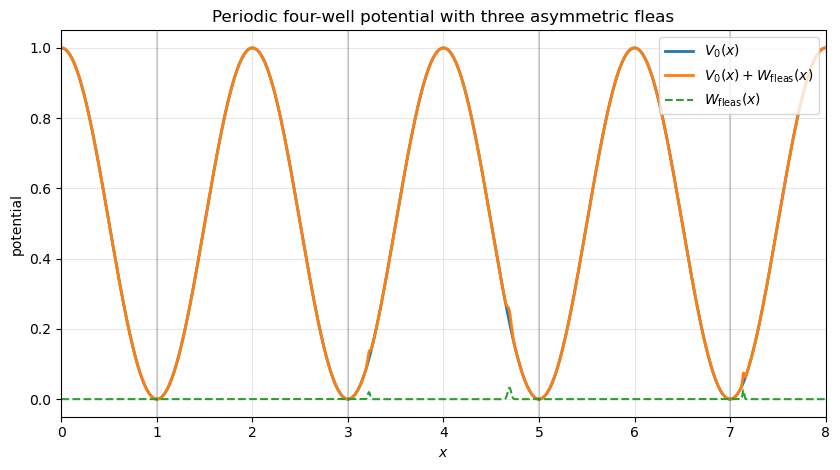

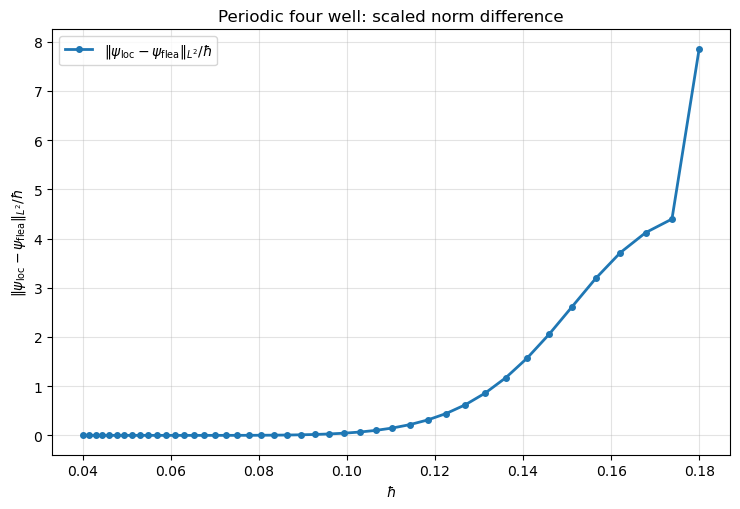

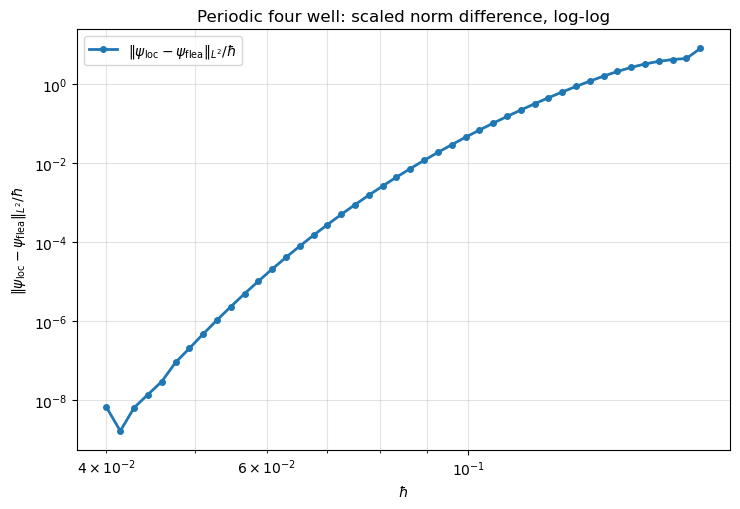

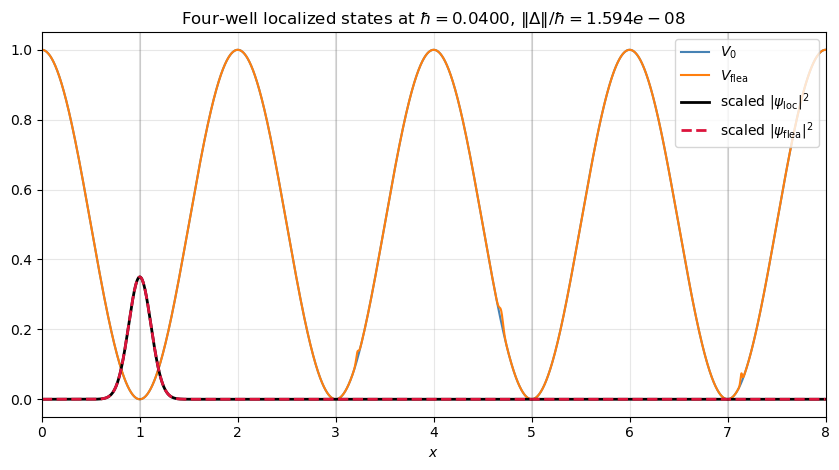

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import diags
from scipy.sparse.linalg import eigsh


# ============================================================
# Periodic grid
# ============================================================

def make_periodic_grid(period=8.0, n_grid=4800):
    """
    Periodic grid on [0, period).

    The endpoint is excluded, so x = 0 and x = period are identified.
    """
    dx = period / n_grid
    x = np.linspace(0.0, period, n_grid, endpoint=False)
    return x, dx


def periodic_distance(x, center, period):
    """
    Signed shortest periodic distance from x to center on a circle of length period.

    Values lie in [-period/2, period/2).
    """
    return (x - center + 0.5 * period) % period - 0.5 * period


# ============================================================
# Periodic four-well potential and fleas
# ============================================================

def periodic_four_well_cos2(x, a=1.0, barrier_height=1.0):
    """
    Periodic four-well potential on [0, 8a):

        V(x) = barrier_height * cos^2(pi x / (2a)).

    Since cos^2(pi x / (2a)) has period 2a, the interval [0, 8a)
    contains exactly four wells.

    Minima occur at

        x = a, 3a, 5a, 7a.
    """
    return barrier_height * np.cos(np.pi * x / (2.0 * a))**2


def smooth_periodic_bump(x, center, width, height, period):
    """
    Smooth compactly supported periodic bump.

    Let r be the shortest periodic distance from x to center. Then

        W(x) = height * exp(1/width^2 - 1/(width^2 - r^2))

    for |r| < width, and 0 otherwise.
    """
    r = periodic_distance(x, center, period)

    W = np.zeros_like(x, dtype=float)
    mask = np.abs(r) < width

    exponent = (1.0 / width**2) - (1.0 / (width**2 - r[mask]**2))
    W[mask] = height * np.exp(exponent)

    return W


def build_asymmetric_three_flea_potential(
    x,
    period,
    well_centers,
    target_well_index=0,
    flea_widths=(0.13, 0.16, 0.11),
    flea_heights=(0.020, 0.033, 0.026),
    flea_offsets=(0.22, -0.31, 0.14)
):
    """
    Add asymmetric positive fleas in the three wells that are NOT the target well.

    This fully breaks the fourfold symmetry.

    Parameters
    ----------
    well_centers:
        Array-like of length 4, e.g. [a, 3a, 5a, 7a].

    target_well_index:
        The well in which we want the final localized state.

    flea_offsets:
        Offsets from the non-target well centers. These are deliberately different.

    flea_widths, flea_heights:
        Widths and heights of the three fleas. These are deliberately different.
    """
    W_total = np.zeros_like(x, dtype=float)

    non_target_indices = [j for j in range(4) if j != target_well_index]

    if not (len(flea_widths) == len(flea_heights) == len(flea_offsets) == 3):
        raise ValueError("flea_widths, flea_heights, and flea_offsets must each have length 3.")

    for k, well_idx in enumerate(non_target_indices):
        center = (well_centers[well_idx] + flea_offsets[k]) % period

        W_total += smooth_periodic_bump(
            x=x,
            center=center,
            width=flea_widths[k],
            height=flea_heights[k],
            period=period
        )

    return W_total


# ============================================================
# Periodic Schrödinger eigensolver
# ============================================================

def build_periodic_hamiltonian_sparse(x, dx, V, hbar, mass=0.5):
    """
    Sparse periodic finite-difference Hamiltonian

        H = -hbar^2 / (2m) d^2/dx^2 + V(x)

    on a periodic grid.

    The periodic second derivative is

        psi''(x_i) ≈ (psi_{i+1} - 2 psi_i + psi_{i-1}) / dx^2,

    with wraparound at the endpoints.
    """
    n = len(x)

    diag_kinetic = hbar**2 / (mass * dx**2)
    offdiag_kinetic = -hbar**2 / (2.0 * mass * dx**2)

    main_diag = diag_kinetic + V
    off_diag = offdiag_kinetic * np.ones(n - 1)

    H = diags(
        diagonals=[off_diag, main_diag, off_diag],
        offsets=[-1, 0, 1],
        format="lil"
    )

    # Periodic wraparound terms
    H[0, -1] = offdiag_kinetic
    H[-1, 0] = offdiag_kinetic

    return H.tocsr()


def solve_lowest_periodic_eigenstates(
    x,
    dx,
    V,
    hbar,
    mass=0.5,
    k=12,
    tol=1e-10
):
    """
    Solve the periodic finite-difference eigenproblem.

    Returned eigenvectors are continuum-normalized:

        dx * sum_i |psi_i|^2 = 1.
    """
    H = build_periodic_hamiltonian_sparse(
        x=x,
        dx=dx,
        V=V,
        hbar=hbar,
        mass=mass
    )

    evals, evecs = eigsh(
        H,
        k=k,
        which="SA",
        tol=tol,
        maxiter=300000
    )

    idx = np.argsort(evals)
    evals = evals[idx]
    evecs = evecs[:, idx]

    # eigsh returns Euclidean-normalized eigenvectors.
    # Convert to continuum L2 normalization.
    evecs = evecs / np.sqrt(dx)

    return evals, evecs


# ============================================================
# L2 utilities
# ============================================================

def l2_inner(dx, psi, phi):
    return dx * np.vdot(psi, phi)


def l2_norm(dx, psi):
    return np.sqrt(np.real(l2_inner(dx, psi, psi)))


def normalize_l2(dx, psi):
    return psi / l2_norm(dx, psi)


def align_phase(dx, reference, psi):
    """
    Align the global phase of psi with reference so that their overlap is real
    and nonnegative.
    """
    overlap = l2_inner(dx, reference, psi)

    if np.abs(overlap) < 1e-14:
        return psi

    return psi * np.exp(-1j * np.angle(overlap))


# ============================================================
# Well-localization tools
# ============================================================

def nearest_well_indices(x, well_centers, period):
    """
    For each grid point x_i, return the index of the nearest well center,
    using periodic distance.
    """
    distances = []
    for c in well_centers:
        distances.append(np.abs(periodic_distance(x, c, period)))

    distances = np.vstack(distances)
    return np.argmin(distances, axis=0)


def well_mask(x, well_centers, target_well_index, period):
    """
    Boolean mask selecting the Voronoi cell of the target well.
    """
    nearest = nearest_well_indices(x, well_centers, period)
    return nearest == target_well_index


def localized_state_from_unperturbed_four_band(
    x,
    dx,
    evecs,
    target_mask
):
    """
    Construct the approximately localized unperturbed state from the lowest
    four unperturbed energy eigenstates.

    We diagonalize the target-well projection operator inside the 4-dimensional
    low-energy band:

        P_target = multiplication by 1_target_cell.

    The eigenvector with largest expectation value of P_target is used as the
    localized state in the target well.
    """
    Phi = evecs[:, :4]

    P_projected = dx * (Phi.conj().T @ (target_mask[:, None] * Phi))

    pvals, coeffs = np.linalg.eigh(P_projected)

    idx = int(np.argmax(pvals))

    psi_loc = Phi @ coeffs[:, idx]
    psi_loc = normalize_l2(dx, psi_loc)

    return psi_loc, pvals[idx]


def choose_flea_state_localized_in_target(
    x,
    dx,
    flea_evecs,
    target_mask,
    n_candidates=12
):
    """
    Among the lowest few flea-perturbed eigenstates, choose the one with
    maximum L2 mass in the target well.
    """
    n_candidates = min(n_candidates, flea_evecs.shape[1])

    best_idx = None
    best_mass = -np.inf

    for j in range(n_candidates):
        psi = flea_evecs[:, j]
        mass_target = dx * np.sum(np.abs(psi[target_mask])**2)

        if mass_target > best_mass:
            best_mass = mass_target
            best_idx = j

    psi_best = normalize_l2(dx, flea_evecs[:, best_idx])

    return psi_best, best_idx, best_mass


# ============================================================
# Main computation
# ============================================================

def compute_four_well_scaled_errors(
    hbars,
    a=1.0,
    n_grid=4800,
    mass=0.5,
    barrier_height=1.0,
    target_well_index=0,
    flea_widths=(0.13, 0.16, 0.11),
    flea_heights=(0.020, 0.033, 0.026),
    flea_offsets=(0.22, -0.31, 0.14),
    n_unperturbed_states=8,
    n_flea_states=12,
    n_flea_candidates=12,
    eig_tol=1e-10
):
    """
    For each hbar, compute:

        psi_loc:
            normalized linear combination of the lowest four unperturbed
            eigenstates, localized in the target well.

        psi_flea:
            flea-perturbed eigenstate localized in the same target well.

    Then compute

        error(hbar) = ||psi_loc - psi_flea||_L2

    and

        scaled_error(hbar) = error(hbar) / hbar.
    """
    period = 8.0 * a
    well_centers = np.array([a, 3.0 * a, 5.0 * a, 7.0 * a])

    x, dx = make_periodic_grid(period=period, n_grid=n_grid)

    V0 = periodic_four_well_cos2(
        x=x,
        a=a,
        barrier_height=barrier_height
    )

    W_fleas = build_asymmetric_three_flea_potential(
        x=x,
        period=period,
        well_centers=well_centers,
        target_well_index=target_well_index,
        flea_widths=flea_widths,
        flea_heights=flea_heights,
        flea_offsets=flea_offsets
    )

    V_flea = V0 + W_fleas

    target_mask = well_mask(
        x=x,
        well_centers=well_centers,
        target_well_index=target_well_index,
        period=period
    )

    errors = []
    scaled_errors = []
    records = []

    for hbar in hbars:
        # ----------------------------------------------------
        # Unperturbed four-well eigenstates
        # ----------------------------------------------------
        evals0, evecs0 = solve_lowest_periodic_eigenstates(
            x=x,
            dx=dx,
            V=V0,
            hbar=hbar,
            mass=mass,
            k=n_unperturbed_states,
            tol=eig_tol
        )

        psi_loc, loc_target_mass = localized_state_from_unperturbed_four_band(
            x=x,
            dx=dx,
            evecs=evecs0,
            target_mask=target_mask
        )

        # ----------------------------------------------------
        # Flea-perturbed eigenstates
        # ----------------------------------------------------
        evals_flea, evecs_flea = solve_lowest_periodic_eigenstates(
            x=x,
            dx=dx,
            V=V_flea,
            hbar=hbar,
            mass=mass,
            k=n_flea_states,
            tol=eig_tol
        )

        psi_flea, flea_idx, flea_target_mass = choose_flea_state_localized_in_target(
            x=x,
            dx=dx,
            flea_evecs=evecs_flea,
            target_mask=target_mask,
            n_candidates=n_flea_candidates
        )

        # Align global phase before subtracting.
        psi_flea = align_phase(dx, psi_loc, psi_flea)

        # ----------------------------------------------------
        # L2 norm difference and scaled difference
        # ----------------------------------------------------
        error = l2_norm(dx, psi_loc - psi_flea)
        scaled_error = error / hbar

        errors.append(error)
        scaled_errors.append(scaled_error)

        records.append({
            "hbar": hbar,
            "error": error,
            "scaled_error": scaled_error,
            "E_unperturbed_0": evals0[0],
            "E_unperturbed_1": evals0[1],
            "E_unperturbed_2": evals0[2],
            "E_unperturbed_3": evals0[3],
            "unperturbed_band_width": evals0[3] - evals0[0],
            "loc_target_mass": loc_target_mass,
            "flea_state_index": flea_idx,
            "E_flea_selected": evals_flea[flea_idx],
            "flea_target_mass": flea_target_mass
        })

        print(
            f"hbar={hbar:10.6f}  "
            f"||diff||={error:12.5e}  "
            f"||diff||/hbar={scaled_error:12.5e}  "
            f"band_width={evals0[3] - evals0[0]:12.5e}  "
            f"loc_mass={loc_target_mass:9.6f}  "
            f"flea_idx={flea_idx:2d}  "
            f"flea_mass={flea_target_mass:9.6f}"
        )

    return {
        "x": x,
        "dx": dx,
        "period": period,
        "well_centers": well_centers,
        "V0": V0,
        "W_fleas": W_fleas,
        "V_flea": V_flea,
        "target_mask": target_mask,
        "hbars": np.array(hbars),
        "errors": np.array(errors),
        "scaled_errors": np.array(scaled_errors),
        "records": records
    }


# ============================================================
# Plotting
# ============================================================

def plot_scaled_errors(results):
    hbars = results["hbars"]
    scaled_errors = results["scaled_errors"]

    order = np.argsort(hbars)
    hbars_sorted = hbars[order]
    scaled_sorted = scaled_errors[order]

    fig, ax = plt.subplots(figsize=(7.5, 5.2))

    ax.plot(
        hbars_sorted,
        scaled_sorted,
        "o-",
        lw=2,
        ms=4,
        label=r"$\|\psi_{\rm loc}-\psi_{\rm flea}\|_{L^2}/\hbar$"
    )

    ax.set_xlabel(r"$\hbar$")
    ax.set_ylabel(r"$\|\psi_{\rm loc}-\psi_{\rm flea}\|_{L^2}/\hbar$")
    ax.set_title(r"Periodic four well: scaled norm difference")
    ax.grid(True, alpha=0.35)
    ax.legend()

    plt.tight_layout()
    plt.show()


def plot_scaled_errors_loglog(results):
    hbars = results["hbars"]
    scaled_errors = results["scaled_errors"]

    order = np.argsort(hbars)
    hbars_sorted = hbars[order]
    scaled_sorted = scaled_errors[order]

    fig, ax = plt.subplots(figsize=(7.5, 5.2))

    ax.loglog(
        hbars_sorted,
        scaled_sorted,
        "o-",
        lw=2,
        ms=4,
        label=r"$\|\psi_{\rm loc}-\psi_{\rm flea}\|_{L^2}/\hbar$"
    )

    ax.set_xlabel(r"$\hbar$")
    ax.set_ylabel(r"$\|\psi_{\rm loc}-\psi_{\rm flea}\|_{L^2}/\hbar$")
    ax.set_title(r"Periodic four well: scaled norm difference, log-log")
    ax.grid(True, which="both", alpha=0.35)
    ax.legend()

    plt.tight_layout()
    plt.show()


def plot_potentials(results):
    x = results["x"]
    V0 = results["V0"]
    W_fleas = results["W_fleas"]
    V_flea = results["V_flea"]
    period = results["period"]
    well_centers = results["well_centers"]

    fig, ax = plt.subplots(figsize=(8.5, 4.8))

    ax.plot(x, V0, lw=2, label=r"$V_0(x)$")
    ax.plot(x, V_flea, lw=2, label=r"$V_0(x)+W_{\rm fleas}(x)$")
    ax.plot(x, W_fleas, "--", lw=1.5, label=r"$W_{\rm fleas}(x)$")

    for c in well_centers:
        ax.axvline(c, color="k", alpha=0.15)

    ax.set_xlim(0.0, period)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel("potential")
    ax.set_title("Periodic four-well potential with three asymmetric fleas")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()


def plot_example_states_for_one_hbar(
    hbar,
    results,
    mass=0.5,
    target_well_index=0,
    n_unperturbed_states=8,
    n_flea_states=12,
    n_flea_candidates=12,
    eig_tol=1e-10
):
    """
    Optional diagnostic plot:
    shows psi_loc and psi_flea densities for one hbar.
    """
    x = results["x"]
    dx = results["dx"]
    V0 = results["V0"]
    V_flea = results["V_flea"]
    period = results["period"]
    well_centers = results["well_centers"]
    target_mask = results["target_mask"]

    evals0, evecs0 = solve_lowest_periodic_eigenstates(
        x=x,
        dx=dx,
        V=V0,
        hbar=hbar,
        mass=mass,
        k=n_unperturbed_states,
        tol=eig_tol
    )

    psi_loc, loc_target_mass = localized_state_from_unperturbed_four_band(
        x=x,
        dx=dx,
        evecs=evecs0,
        target_mask=target_mask
    )

    evals_flea, evecs_flea = solve_lowest_periodic_eigenstates(
        x=x,
        dx=dx,
        V=V_flea,
        hbar=hbar,
        mass=mass,
        k=n_flea_states,
        tol=eig_tol
    )

    psi_flea, flea_idx, flea_target_mass = choose_flea_state_localized_in_target(
        x=x,
        dx=dx,
        flea_evecs=evecs_flea,
        target_mask=target_mask,
        n_candidates=n_flea_candidates
    )

    psi_flea = align_phase(dx, psi_loc, psi_flea)

    fig, ax = plt.subplots(figsize=(8.5, 4.8))

    ax.plot(x, V0, color="steelblue", lw=1.5, label=r"$V_0$")
    ax.plot(x, V_flea, color="tab:orange", lw=1.5, label=r"$V_{\rm flea}$")

    # Scale densities visually to fit potential plot
    scale = 0.35 / max(np.max(np.abs(psi_loc)**2), np.max(np.abs(psi_flea)**2))

    ax.plot(
        x,
        scale * np.abs(psi_loc)**2,
        color="black",
        lw=2,
        label=r"scaled $|\psi_{\rm loc}|^2$"
    )

    ax.plot(
        x,
        scale * np.abs(psi_flea)**2,
        color="crimson",
        lw=2,
        ls="--",
        label=r"scaled $|\psi_{\rm flea}|^2$"
    )

    for c in well_centers:
        ax.axvline(c, color="k", alpha=0.12)

    ax.set_xlim(0.0, period)
    ax.set_xlabel(r"$x$")
    ax.set_title(
        rf"Four-well localized states at $\hbar={hbar:.4f}$, "
        rf"$\|\Delta\|/\hbar={l2_norm(dx, psi_loc - psi_flea) / hbar:.3e}$"
    )
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()


# ============================================================
# Run script
# ============================================================

if __name__ == "__main__":

    # Many small hbar values.
    #
    # If you push hbar much smaller, increase n_grid.
    hbars = np.geomspace(0.18, 0.04, 44)

    results = compute_four_well_scaled_errors(
        hbars=hbars,

        # Four-well geometry
        a=1.0,
        n_grid=4800,
        barrier_height=1.0,

        # Schrödinger operator
        mass=0.5,

        # Target well:
        # well_centers are [a, 3a, 5a, 7a].
        # target_well_index = 0 means localize near x = a.
        target_well_index=0,

        # Three asymmetric fleas in the three non-target wells.
        # These are deliberately different to fully break C4 symmetry.
        flea_widths=(0.13, 0.16, 0.11),
        flea_heights=(0.020, 0.033, 0.026),
        flea_offsets=(0.22, -0.31, 0.14),

        # Eigenstate settings
        n_unperturbed_states=8,
        n_flea_states=12,
        n_flea_candidates=12,
        eig_tol=1e-10
    )

    plot_potentials(results)
    plot_scaled_errors(results)
    plot_scaled_errors_loglog(results)

    # Optional diagnostic state plot at the smallest hbar.
    plot_example_states_for_one_hbar(
        hbar=results["hbars"][-1],
        results=results,
        mass=0.5,
        target_well_index=0,
        n_unperturbed_states=8,
        n_flea_states=12,
        n_flea_candidates=12,
        eig_tol=1e-10
    )